We compare the performance of linear regularization methods applied to two-dimensional deconvolution problems:
We try to find a non-negative function f given data 
$$
    d \sim \mathrm{Pois}(h*f)
$$
with a non-negative convolution kernel $h$, and $\mathrm{Pois}$ denotes the element-wise Poisson distribution.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mplib
from regpy.operators import CoordinateProjection 
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import RegularizationSetting
from regpy.solvers.linear.tikhonov import TikhonovCG, TikhonovAlphaGrid, NonstationaryIteratedTikhonov
from regpy.solvers.linear.landweber import Landweber
from regpy.hilbert import L2, HmDomain
import regpy.stoprules as rules
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-20s :: %(message)s'
)

We first introduce a plotting routine for comparing reconstructions and originals using the same color scale and access colors.  

In [60]:
def comparison_plot(grid,truth,reco,title_right='exact',title_left='reconstruction',residual=None):
    plt.rcParams.update({'font.size': 22})
    extent = [grid.axes[0][0],grid.axes[0][-1], grid.axes[1][0], grid.axes[1][-1]]
    maxval = np.max(truth[:]); minval = np.min(truth[:])
    mycmap = mplib.colormaps['hot']
    mycmap.set_over((0,0,1.,1.))  # use blue as access color for large values
    mycmap.set_under((0,1,0,1.))  # use green as access color for small values
    if not (residual is None):
        fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize = (22,16))
    else:
        fig, (ax1,ax2) = plt.subplots(1,2,figsize = (22,8))
    im1= ax1.imshow(reco.T,extent=extent,origin='lower',
                    vmin=1.05*minval-0.05*maxval, vmax =1.05*maxval-0.05*minval,
                    cmap=mycmap
                    )
    ax1.title.set_text(title_left)
    fig.colorbar(im1,extend='both')
    im2= ax2.imshow(truth.T,extent=extent, origin='lower',
                    vmin=1.05*minval-0.05*maxval, vmax =1.05*maxval-0.05*minval,
                    cmap=mycmap
                    )
    ax2.title.set_text(title_right)
    fig.colorbar(im2,extend='both',orientation='vertical')
    if not (residual is None):
        maxv = np.max(reco[:]-truth[:])
        im3 = ax3.imshow(reco.T-truth.T,extent=extent, origin='lower',vmin= -maxv,vmax=maxv,cmap='RdYlBu')
        ax3.title.set_text('reconstruction error')
        fig.colorbar(im3)

        maxv = np.max(residual[:])
        im4 = ax4.imshow(residual.T,extent=extent, origin='lower',vmin= -maxv,vmax=maxv,cmap='RdYlBu')
        ax4.title.set_text('data residual')
        fig.colorbar(im4)

Define test objects 

(Try other test objects by uncommenting the corresponding lines!)

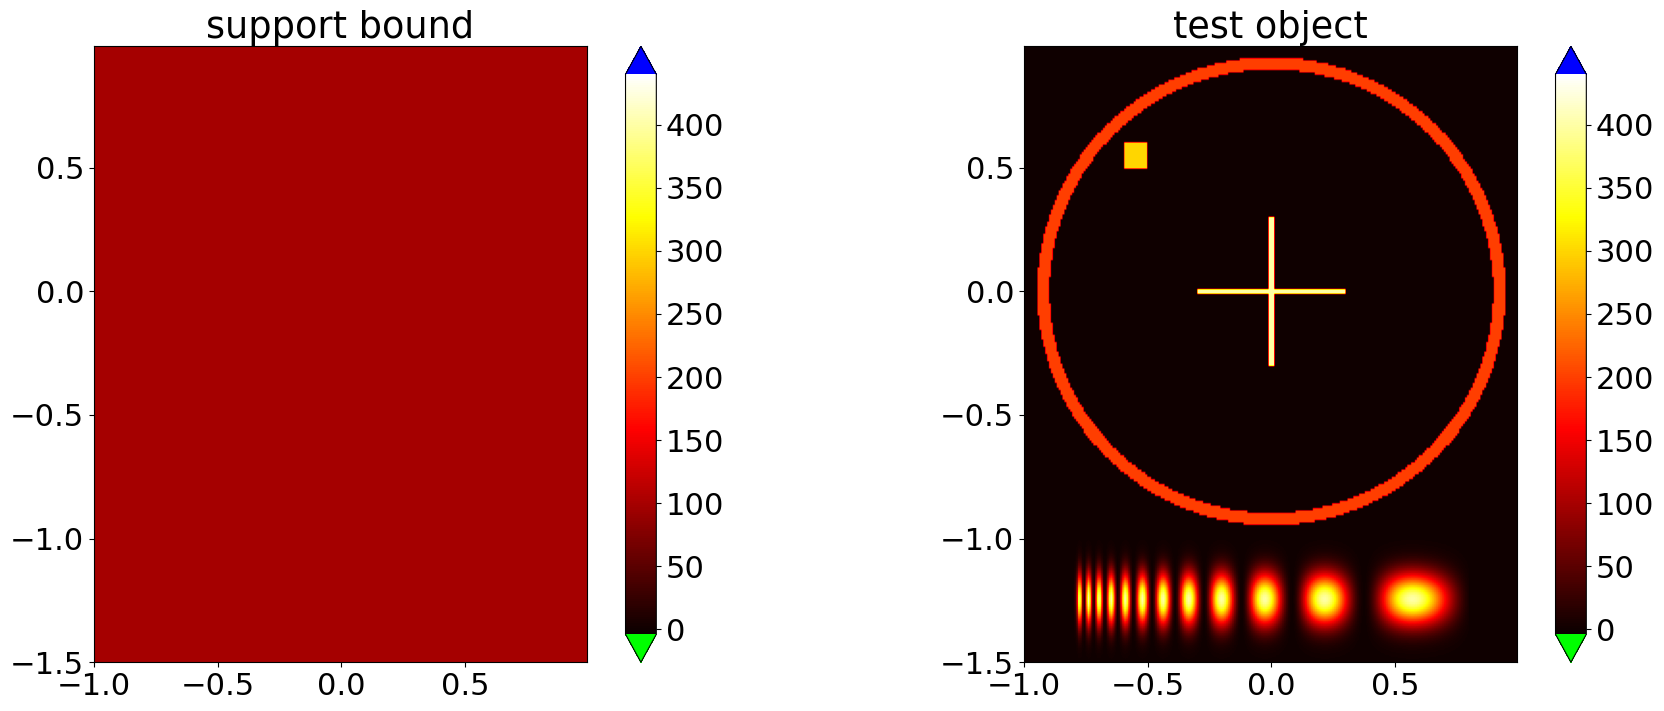

In [61]:
grid = UniformGridFcts((-1, 1, 256), (-1.5, 1, 256),dtype = float, periodic = True)
"""Space of real-valued functions on a uniform grid with rectangular pixels"""
X = grid.coords[0]; Y = grid.coords[1]
"""x and y coordinates."""
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(X**2 + Y**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.95)
smallbox = (abs(X+0.55)<=0.05) * (abs(Y-0.55)<=0.05)
bubbles = (1.001+np.sin(50/(X+1.3)))*np.exp(-((Y+1.25)/0.1)**2)*(X>-0.8)*(X<0.8)

hills = 200*(1+  np.sin(100*(Y*X+X**2)))*np.exp(-(X/0.3)**2 - ((Y+0.25)/0.4)**2)
hills2 =  200*(1+  np.sin(25*(Y*X+0.2*X**2)))*np.exp(-(X/0.3)**2 - ((Y+0.25)/0.4)**2)

objects = 200*(ring + 2.0*cross + 1.5*smallbox + bubbles)
exact_sol = objects; support_bound = exact_sol>=0
#exact_sol = hills; support_bound = np.exp(-(X/0.3)**2 - ((Y+0.25)/0.4)**2)>0.001
#exact_sol = hills2; support_bound = np.exp(-(X/0.3)**2 - ((Y+0.25)/0.4)**2)>0.001
 
comparison_plot(grid,exact_sol,100*support_bound,title_left='support bound',title_right='test object')


Create convolution operator and noisy simulated data

For the case of convolution with \(exp(-|x|/a))\) rather than convolution with a Gaussian, the problem is much less ill-posed, and reconstruction results are better. (Try by uncommenting this line!) 

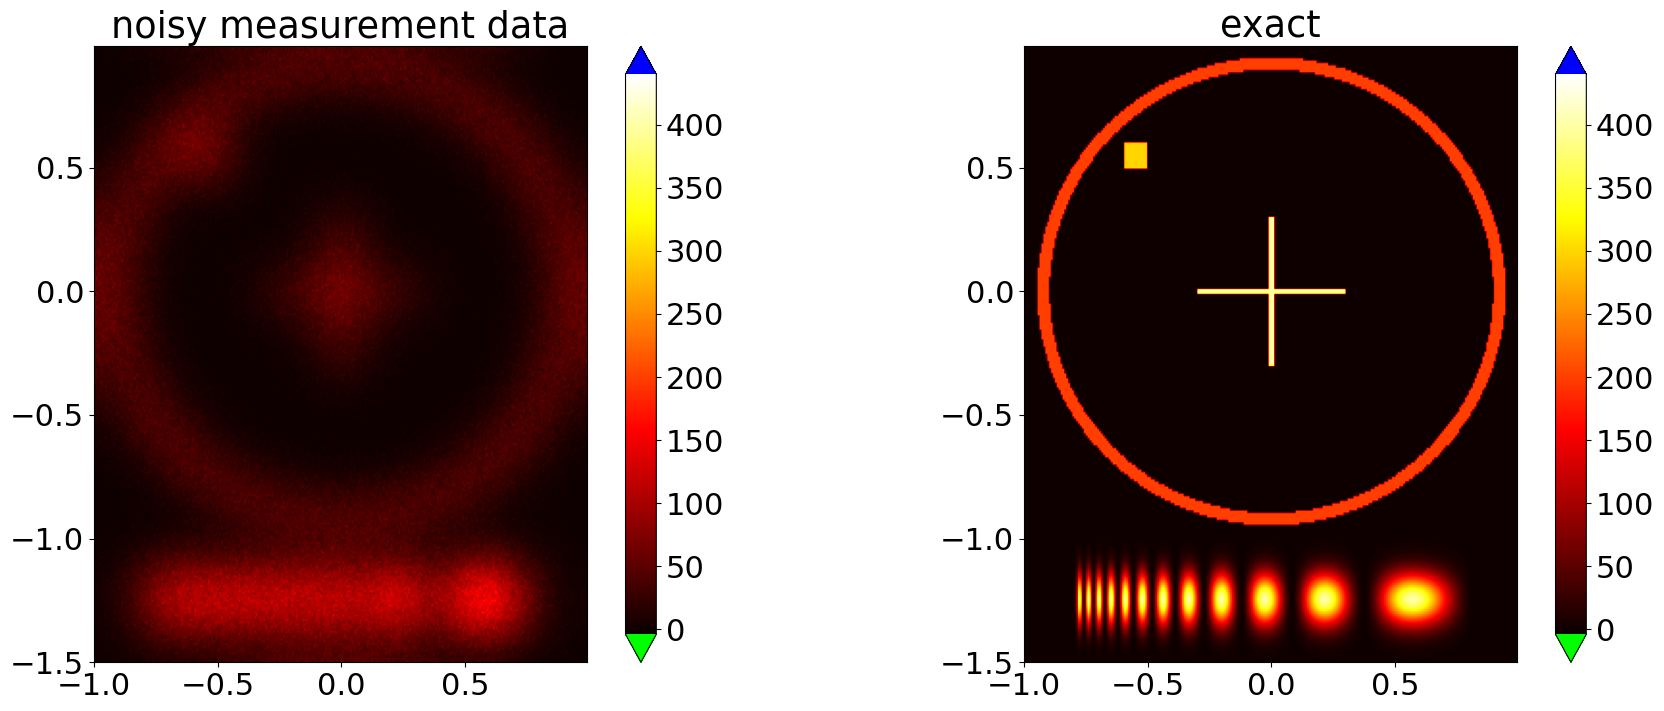

In [62]:
a=0.15
conv = GaussianBlur(grid,a)
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|_2^2/a^2)\)."""
#conv = ExponentialConvolution(grid,a)
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|_1/a)\)."""

blur = conv(exact_sol)
blur[blur<0] = 0.
"""Simulated exact data."""
data = np.random.poisson(blur)
"""Simulated measured data. The Poisson distribution occurs if photon count detectors are used."""
comparison_plot(grid,exact_sol,data,title_left='noisy measurement data')

We first apply Tikhonov regularization in Fourier space. Recall that a convolution operator is given in Fourier space by $T=F^* M_H F$ with a multiplication operator $M_H$, and the multiplier function $H$, often called object transfer function, is the Fourier transform of the convolution kernel. Hence, the Tikhonov estimator has the following simple representation in Fourier space:
$$
(T^*T+\alpha I)^{-1}T^* =  F^* M_r F \qquad \text{with}\qquad r = \frac{\overline{H}}{\alpha + |H|^2} \approx \frac{1}{H}.
$$
We choose $\alpha$ by Morozov's discrepancy principle, i.e. (roughly) the largest value for which the residual $\|Tf-\mathrm{data}\|$ is smaller than the noise level.
Since for Poisson distributed random variable the expectation equals the variance, the noiselevel can be estimated by
$$
 \|\mathrm{data}-\mathrm{blur}\|_2  \approx \|\sqrt{\mathrm{data}}\|_2.
$$

alpha= 0.5 rel. discrepancy= 4.342799995741431
alpha= 0.25 rel. discrepancy= 3.268365859506768
alpha= 0.125 rel. discrepancy= 2.3733142299661187
alpha= 0.0625 rel. discrepancy= 1.7518509987323585
alpha= 0.03125 rel. discrepancy= 1.3771578628031425
alpha= 0.015625 rel. discrepancy= 1.1767303314406745
alpha= 0.0078125 rel. discrepancy= 1.0798922749976463
alpha= 0.00390625 rel. discrepancy= 1.036311041534663
alpha= 0.001953125 rel. discrepancy= 1.0175658111522108
alpha= 0.0009765625 rel. discrepancy= 1.0097021674691444
alpha= 0.00048828125 rel. discrepancy= 1.0063608612545096
alpha= 0.000244140625 rel. discrepancy= 1.0048335272761568
alpha= 0.0001220703125 rel. discrepancy= 1.0040384388053416
alpha= 6.103515625e-05 rel. discrepancy= 1.0035571793487914
alpha= 3.0517578125e-05 rel. discrepancy= 1.0032274296149852
alpha= 1.52587890625e-05 rel. discrepancy= 1.0029743496008408
alpha= 7.62939453125e-06 rel. discrepancy= 1.0027564888968024
alpha= 3.814697265625e-06 rel. discrepancy= 1.0025568988

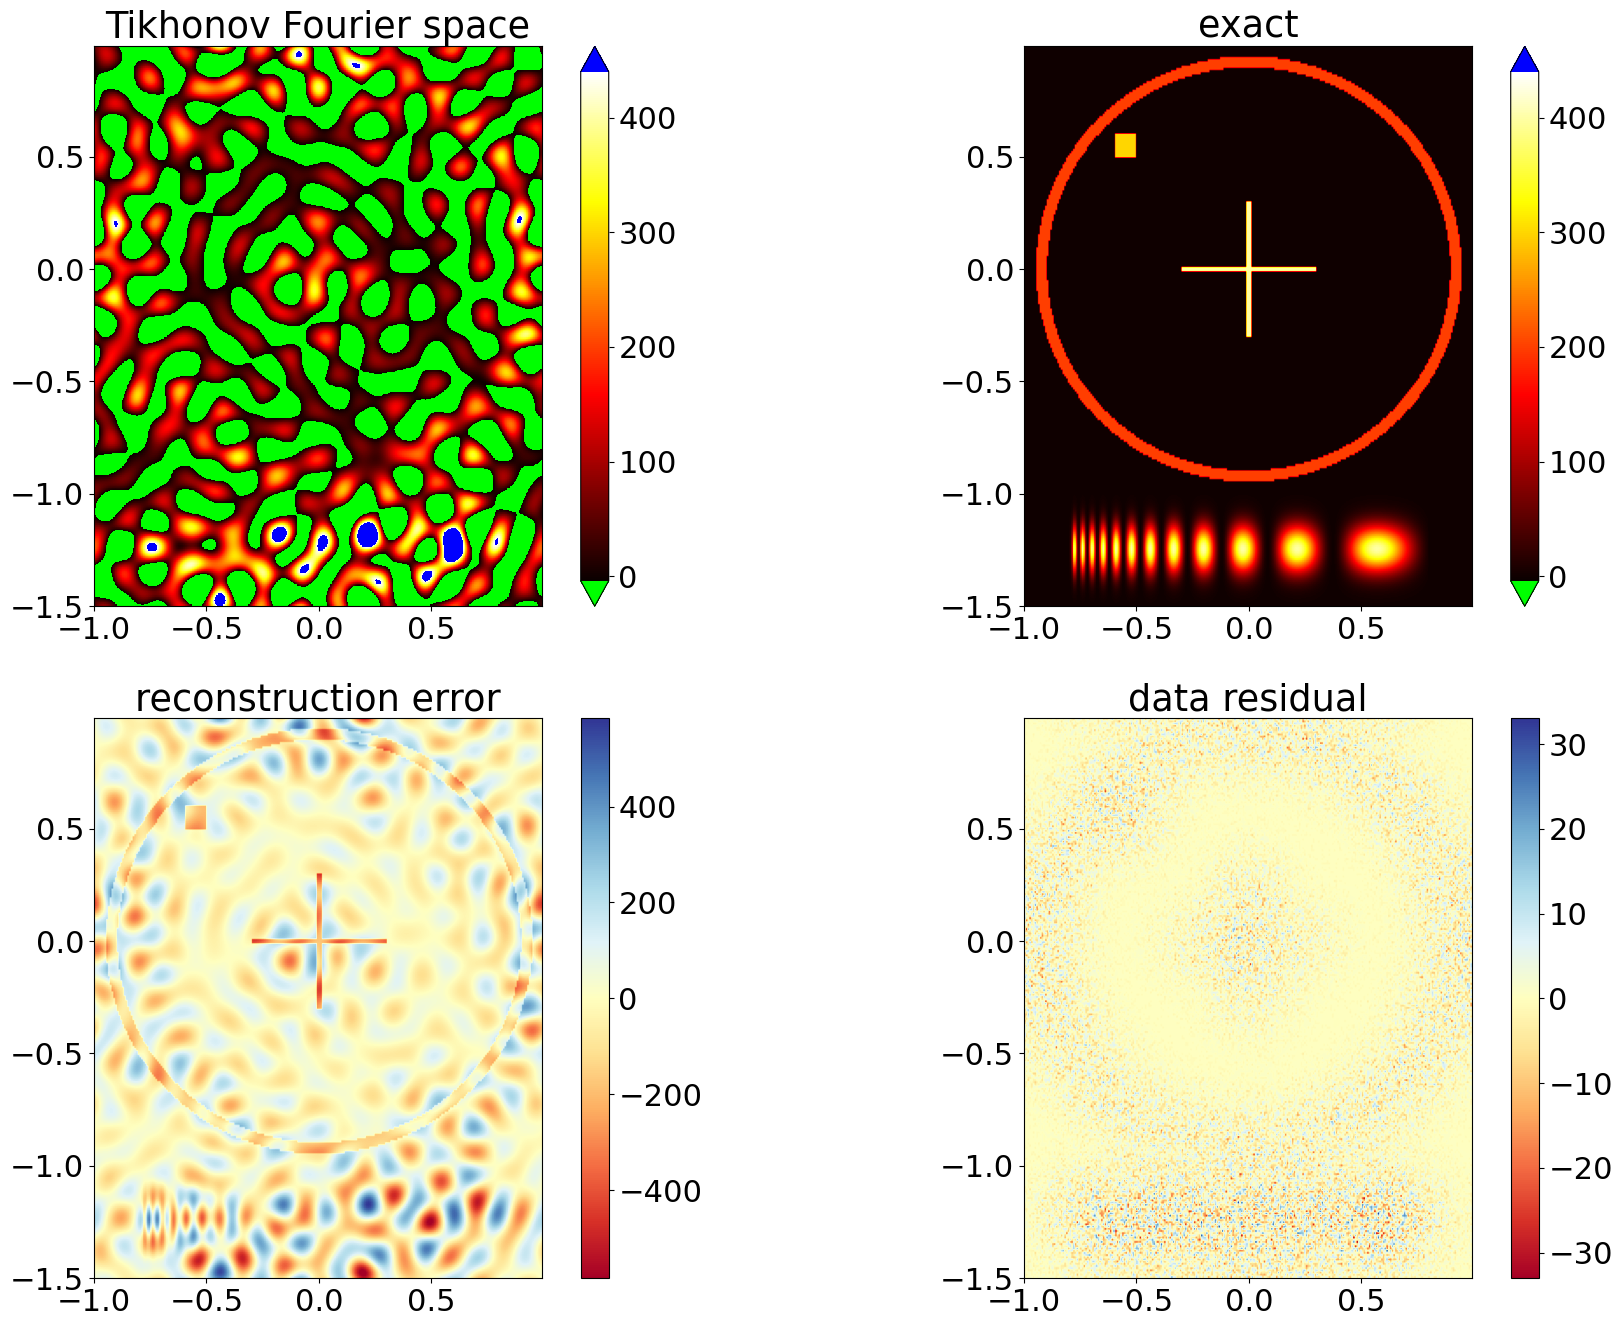

In [63]:
alpha = 1e-0
# inital regularization parameter. (Should be chosen too large.)
otf = conv.fourier_multiplier
# The Fourier transform of the convolution kernel, often called "object transfer function"
reco_op= ConvolutionOperator(grid, np.conj(otf)/(np.abs(otf)**2+alpha))
# The Tikhonov reconstruction operator
reco = reco_op(data)
# Estimator of the true solution
it=0
while np.linalg.norm(conv(reco)[:]-data[:])>np.linalg.norm(np.sqrt(data[:])) and it <20:
    it = it+1
    alpha = alpha/2
    print('alpha=',alpha, 'rel. discrepancy=', np.linalg.norm(conv(reco)[:]-data[:])/np.linalg.norm(np.sqrt(data[:])))
    reco_op= ConvolutionOperator(grid, np.conj(otf)/(np.abs(otf)**2+alpha))
    reco = reco_op(data)

print('relative reconstruction error:', np.linalg.norm(reco[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,reco,title_left='Tikhonov Fourier space',residual = conv(reco)-data)

We now use Landweber iteration 
$$
f_{n+1} = f_n - \mu T^*(Tf_{n}-\mathrm{data}), n=0,1,2
$$
and again stop the iteration by the discrepancy principle. The step-length parameter is chosen $\mu= 1/\|T^*T\|$ where the operator norm (equal to the largest eigenvalue) is estimated by Lanczos' method. 

2024-04-18 10:29:40,693 INFO CountIterations      :: iteration = 0 / 1000
2024-04-18 10:29:40,700 INFO Discrepancy          :: relative discrepancy = 7.38, tolerance = 1.00
2024-04-18 10:29:40,735 INFO Landweber            :: |residual| = 83.78679702648283
2024-04-18 10:29:40,750 INFO CountIterations      :: iteration = 1 / 1000
2024-04-18 10:29:40,754 INFO Discrepancy          :: relative discrepancy = 2.56, tolerance = 1.00
2024-04-18 10:29:40,769 INFO Landweber            :: |residual| = 29.090881982836322
2024-04-18 10:29:40,770 INFO CountIterations      :: iteration = 2 / 1000
2024-04-18 10:29:40,773 INFO Discrepancy          :: relative discrepancy = 1.98, tolerance = 1.00
2024-04-18 10:29:40,787 INFO Landweber            :: |residual| = 22.418167343525035
2024-04-18 10:29:40,789 INFO CountIterations      :: iteration = 3 / 1000
2024-04-18 10:29:40,791 INFO Discrepancy          :: relative discrepancy = 1.72, tolerance = 1.00
2024-04-18 10:29:40,806 INFO Landweber            :: |

relative reconstruction error: 0.6805553897481676


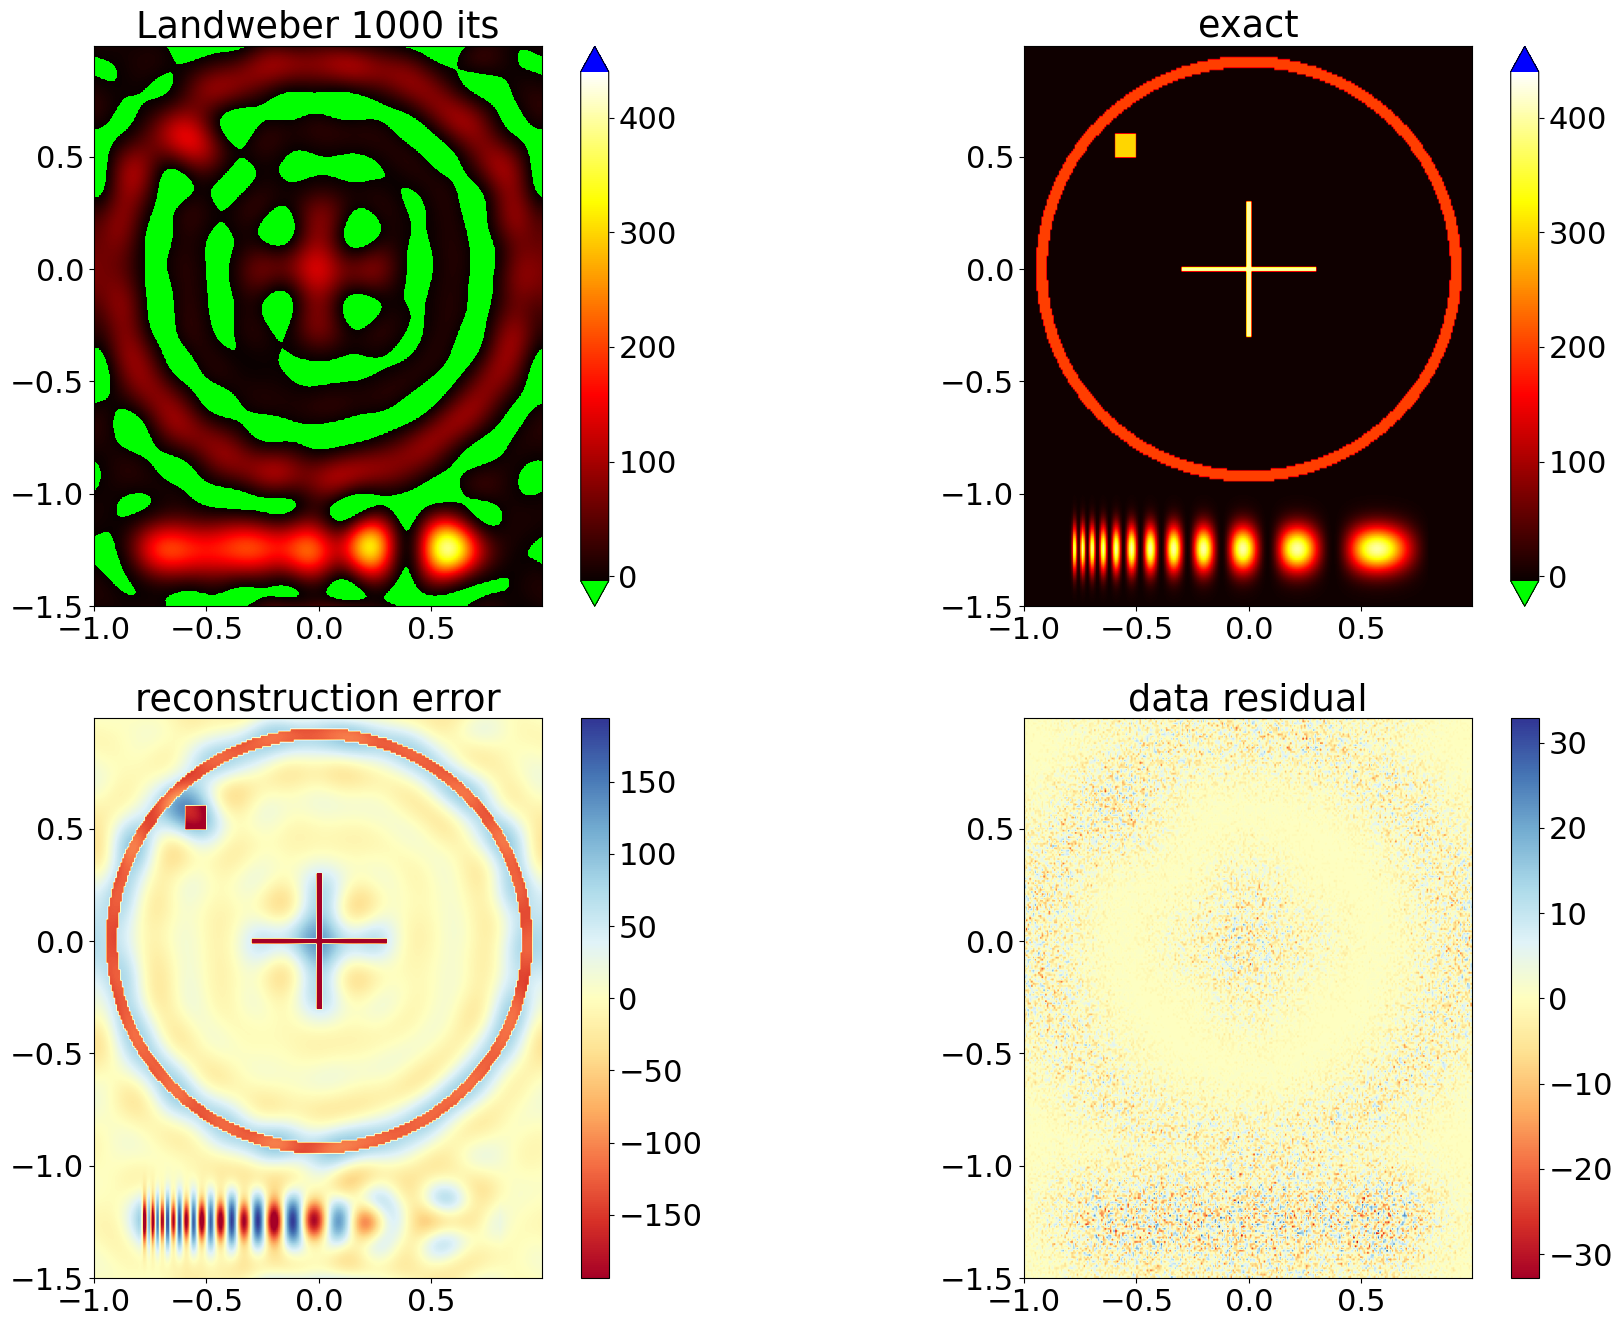

In [64]:
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=L2)
solver = Landweber(setting, data,grid.zeros())
max_its= 1000
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=L2)
stoprule =  (rules.CountIterations(max_iterations=max_its)
   +rules.Discrepancy(setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(np.sqrt(data[:])), tau=1.0)
)
reco, reco_data = solver.run(stoprule)
print('relative reconstruction error:', np.linalg.norm(reco[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,reco,title_left="Landweber {} its".format(solver.iteration_step_nr),residual = reco_data-data)

We now choose the Gram matrix in the image space as approximation of the covariance matrix of the data such that the fitting of the data locally matches the variance of the noise. Recall that the true covariance matrix for Poisson data is the diagonal matrix with the expectation as diagonal.

2024-04-18 10:30:15,869 INFO CountIterations      :: iteration = 0 / 1000
2024-04-18 10:30:15,871 INFO Discrepancy          :: relative discrepancy = 7.38, tolerance = 1.00
2024-04-18 10:30:15,888 INFO Landweber            :: |residual| = 11.169629388073794
2024-04-18 10:30:15,889 INFO CountIterations      :: iteration = 1 / 1000
2024-04-18 10:30:15,892 INFO Discrepancy          :: relative discrepancy = 7.11, tolerance = 1.00
2024-04-18 10:30:15,910 INFO Landweber            :: |residual| = 10.576342487153035
2024-04-18 10:30:15,912 INFO CountIterations      :: iteration = 2 / 1000
2024-04-18 10:30:15,919 INFO Discrepancy          :: relative discrepancy = 6.88, tolerance = 1.00
2024-04-18 10:30:15,935 INFO Landweber            :: |residual| = 10.115513225226277
2024-04-18 10:30:15,936 INFO CountIterations      :: iteration = 3 / 1000
2024-04-18 10:30:15,938 INFO Discrepancy          :: relative discrepancy = 6.67, tolerance = 1.00
2024-04-18 10:30:15,954 INFO Landweber            :: 

relative reconstruction error: 0.7270406220399751


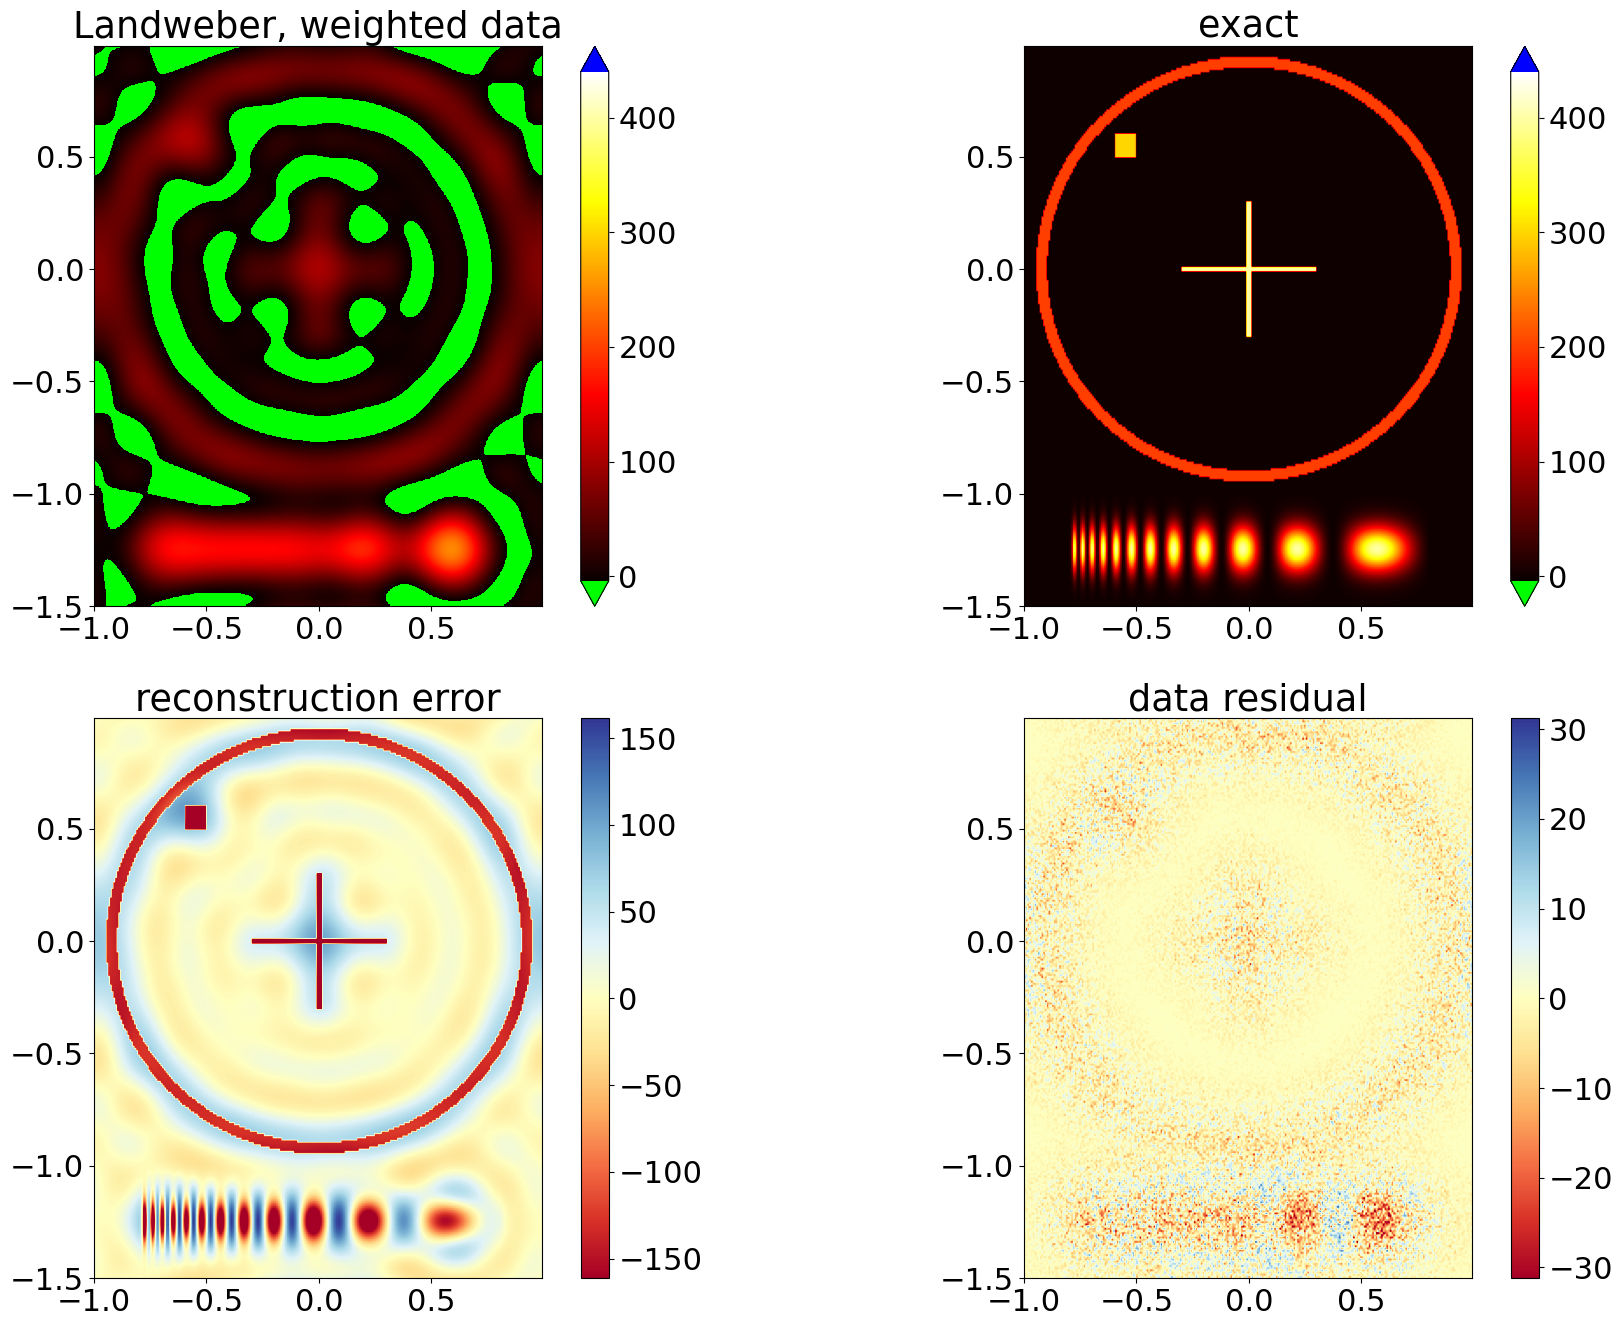

In [65]:
h_codomain = L2(grid, weights = 1./(1.+data)) 
# We estimate the expectation (i.e. blur) by the data and add 1 to avoid zeros.
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=h_codomain)
solver = Landweber(setting, data,grid.zeros())
max_its= 1000
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=L2)
stoprule =  (rules.CountIterations(max_iterations=max_its)
   +rules.Discrepancy(setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(np.sqrt(data[:])), tau=1.0)
)
reco, reco_data = solver.run(stoprule)
print('relative reconstruction error:', np.linalg.norm(reco[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,reco,title_left="Landweber, weighted data".format(solver.iteration_step_nr),residual= reco_data-data)

We now apply Tikhonov regularization with norm in the image space approximating the covariance matrix of the data and hence the negative log-likelihood. 
In this case the Tikhonov estimator can no longer be computed in Fourier space. Instead, we minimize the Tikhonov functional by the conjugate gradient method. The regularization parameter is again chosen by the discrepancy principle. Similar results are obtained by iterated Tikhonov regularization 
$$
f_{n+1} = \mathrm{argmin}_f \left[\|Tf-\mathrm{data}\|^2+ \alpha_n \|f-f_n\|^2\right].
$$

2024-04-18 10:30:54,749 INFO CountIterations      :: iteration = 0 / 50
2024-04-18 10:30:54,772 INFO Discrepancy          :: relative discrepancy = 7.38, tolerance = 1.05
2024-04-18 10:30:54,974 INFO NonstationaryIteratedTikhonov :: alpha_eff = 0.1, inner CG its = 3
2024-04-18 10:30:54,976 INFO CountIterations      :: iteration = 1 / 50
2024-04-18 10:30:54,982 INFO Discrepancy          :: relative discrepancy = 6.50, tolerance = 1.05
2024-04-18 10:30:55,068 INFO NonstationaryIteratedTikhonov :: alpha_eff = 0.03333333333333333, inner CG its = 3
2024-04-18 10:30:55,069 INFO CountIterations      :: iteration = 2 / 50
2024-04-18 10:30:55,074 INFO Discrepancy          :: relative discrepancy = 5.98, tolerance = 1.05
2024-04-18 10:30:55,212 INFO NonstationaryIteratedTikhonov :: alpha_eff = 0.014285714285714285, inner CG its = 5
2024-04-18 10:30:55,213 INFO CountIterations      :: iteration = 3 / 50
2024-04-18 10:30:55,217 INFO Discrepancy          :: relative discrepancy = 5.13, tolerance = 

relative reconstruction error: 0.7207674204050889


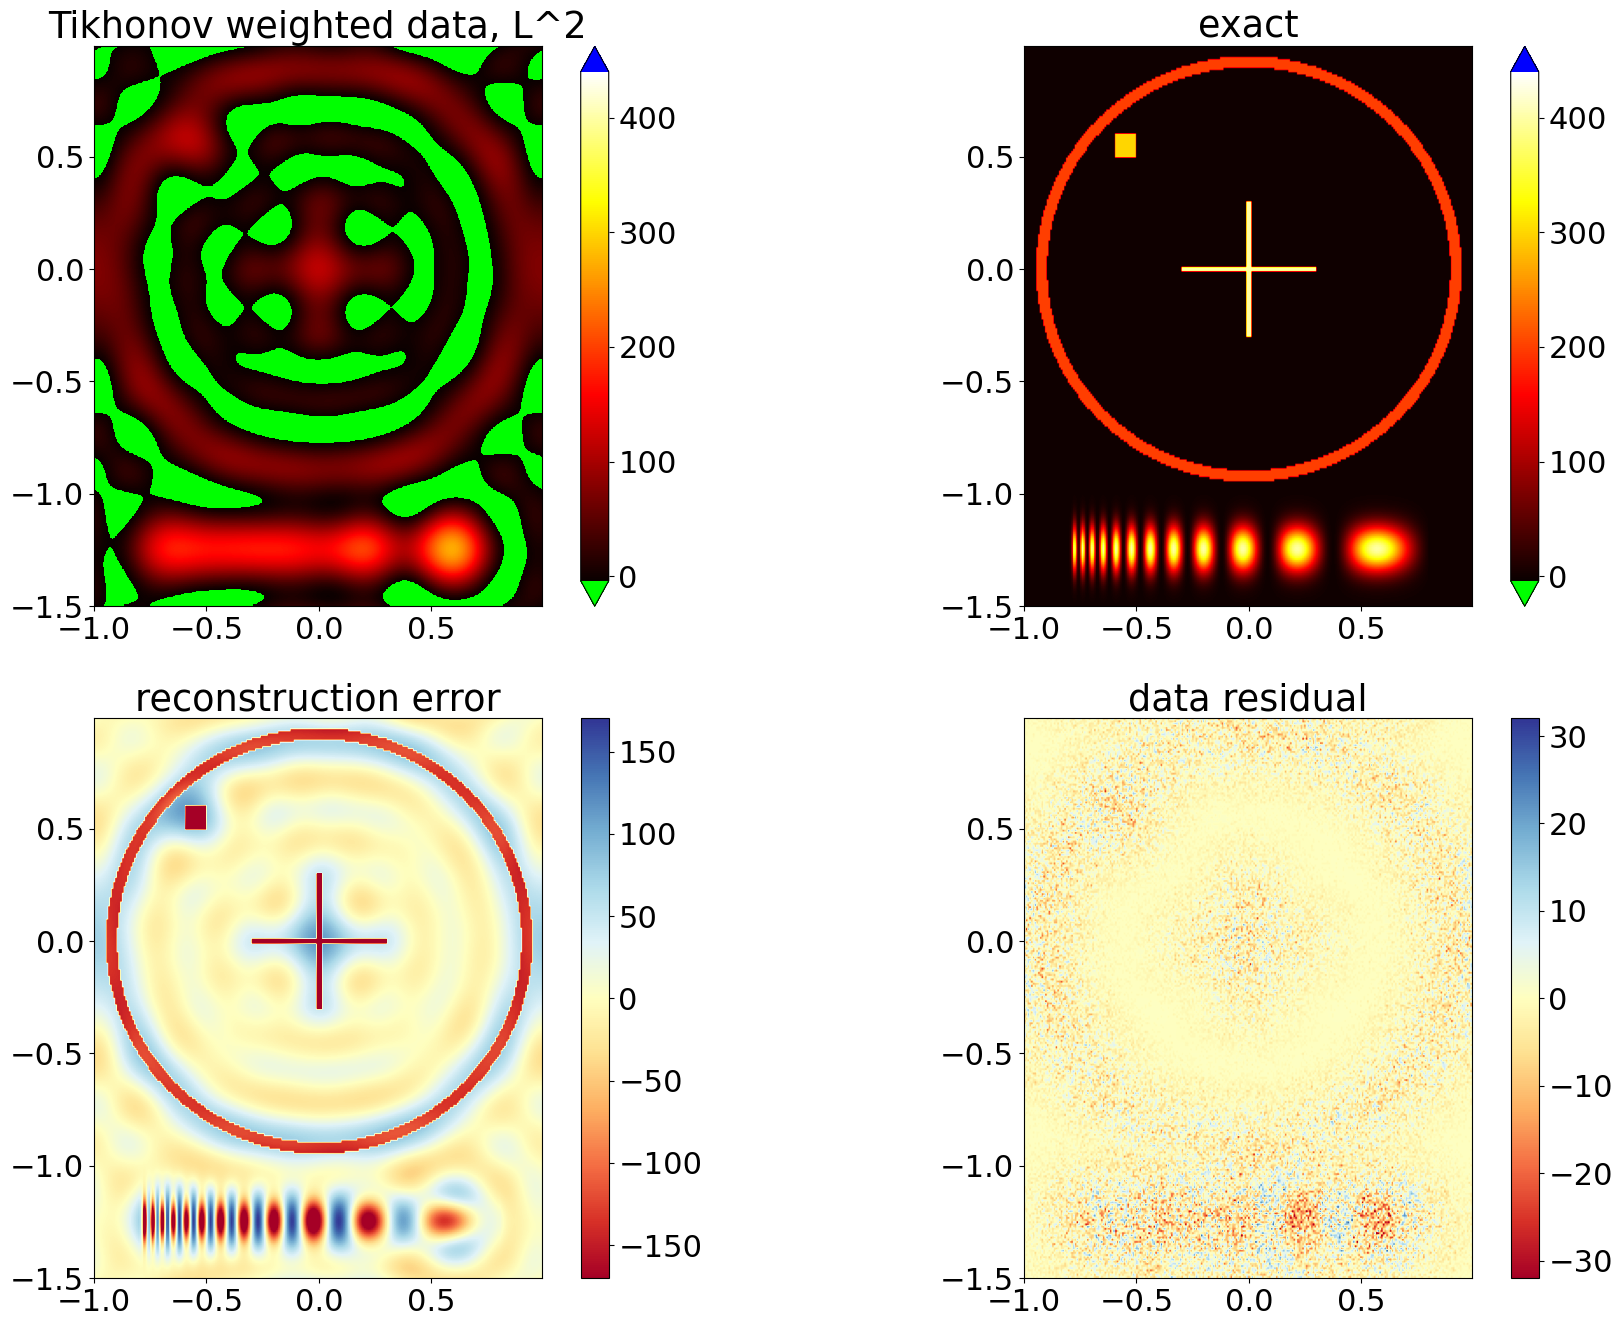

In [66]:
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=h_codomain)
#solver = TikhonovAlphaGrid(setting,data,(1e-2,0.5))
solver = NonstationaryIteratedTikhonov(setting,data,(1e-1,0.5))
max_its= 50
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=L2)
stoprule =  (rules.CountIterations(max_iterations=max_its)
   +rules.Discrepancy(setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(np.sqrt(data[:])), tau=1.05)
)
reco, reco_data = solver.run(stoprule)
print('relative reconstruction error:', np.linalg.norm(reco[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,reco,title_left="Tikhonov weighted data, L^2",residual=reco_data-data)


Finally, we restrict the unknown function to some subdomain $D$ containing the support of the true function (can be the whole domain) and use a Sobolev penalty term. The corresponding inner product is given by 
$$
\langle f_1,f_2\rangle_{H^m(D)} = \langle f_1, (I-\Delta)^{-m} f_w \rangle_{L^2(D)} 
$$
with the Laplace operator $\Delta$ and some index $m=0,1,2,...$. By default, Dirichlet boundary conditions are imposed on the boundary of $\partial D$. If $D$ shares part or all of the boundary with the full rectangle, Neumann boundary conditions are imposed on these parts

2024-04-18 10:31:05,102 INFO CountIterations      :: iteration = 0 / 20
2024-04-18 10:31:05,105 INFO Discrepancy          :: relative discrepancy = 5.59, tolerance = 1.02
2024-04-18 10:31:06,886 INFO NonstationaryIteratedTikhonov :: alpha_eff = 1e-06, inner CG its = 4
2024-04-18 10:31:06,888 INFO CountIterations      :: iteration = 1 / 20
2024-04-18 10:31:06,895 INFO Discrepancy          :: relative discrepancy = 3.99, tolerance = 1.02
2024-04-18 10:31:07,230 INFO NonstationaryIteratedTikhonov :: alpha_eff = 3.3333333333333335e-07, inner CG its = 6
2024-04-18 10:31:07,232 INFO CountIterations      :: iteration = 2 / 20
2024-04-18 10:31:07,237 INFO Discrepancy          :: relative discrepancy = 3.40, tolerance = 1.02
2024-04-18 10:31:07,564 INFO NonstationaryIteratedTikhonov :: alpha_eff = 1.4285714285714285e-07, inner CG its = 6
2024-04-18 10:31:07,567 INFO CountIterations      :: iteration = 3 / 20
2024-04-18 10:31:07,570 INFO Discrepancy          :: relative discrepancy = 2.97, toler

relative reconstruction error: 0.715398359790936


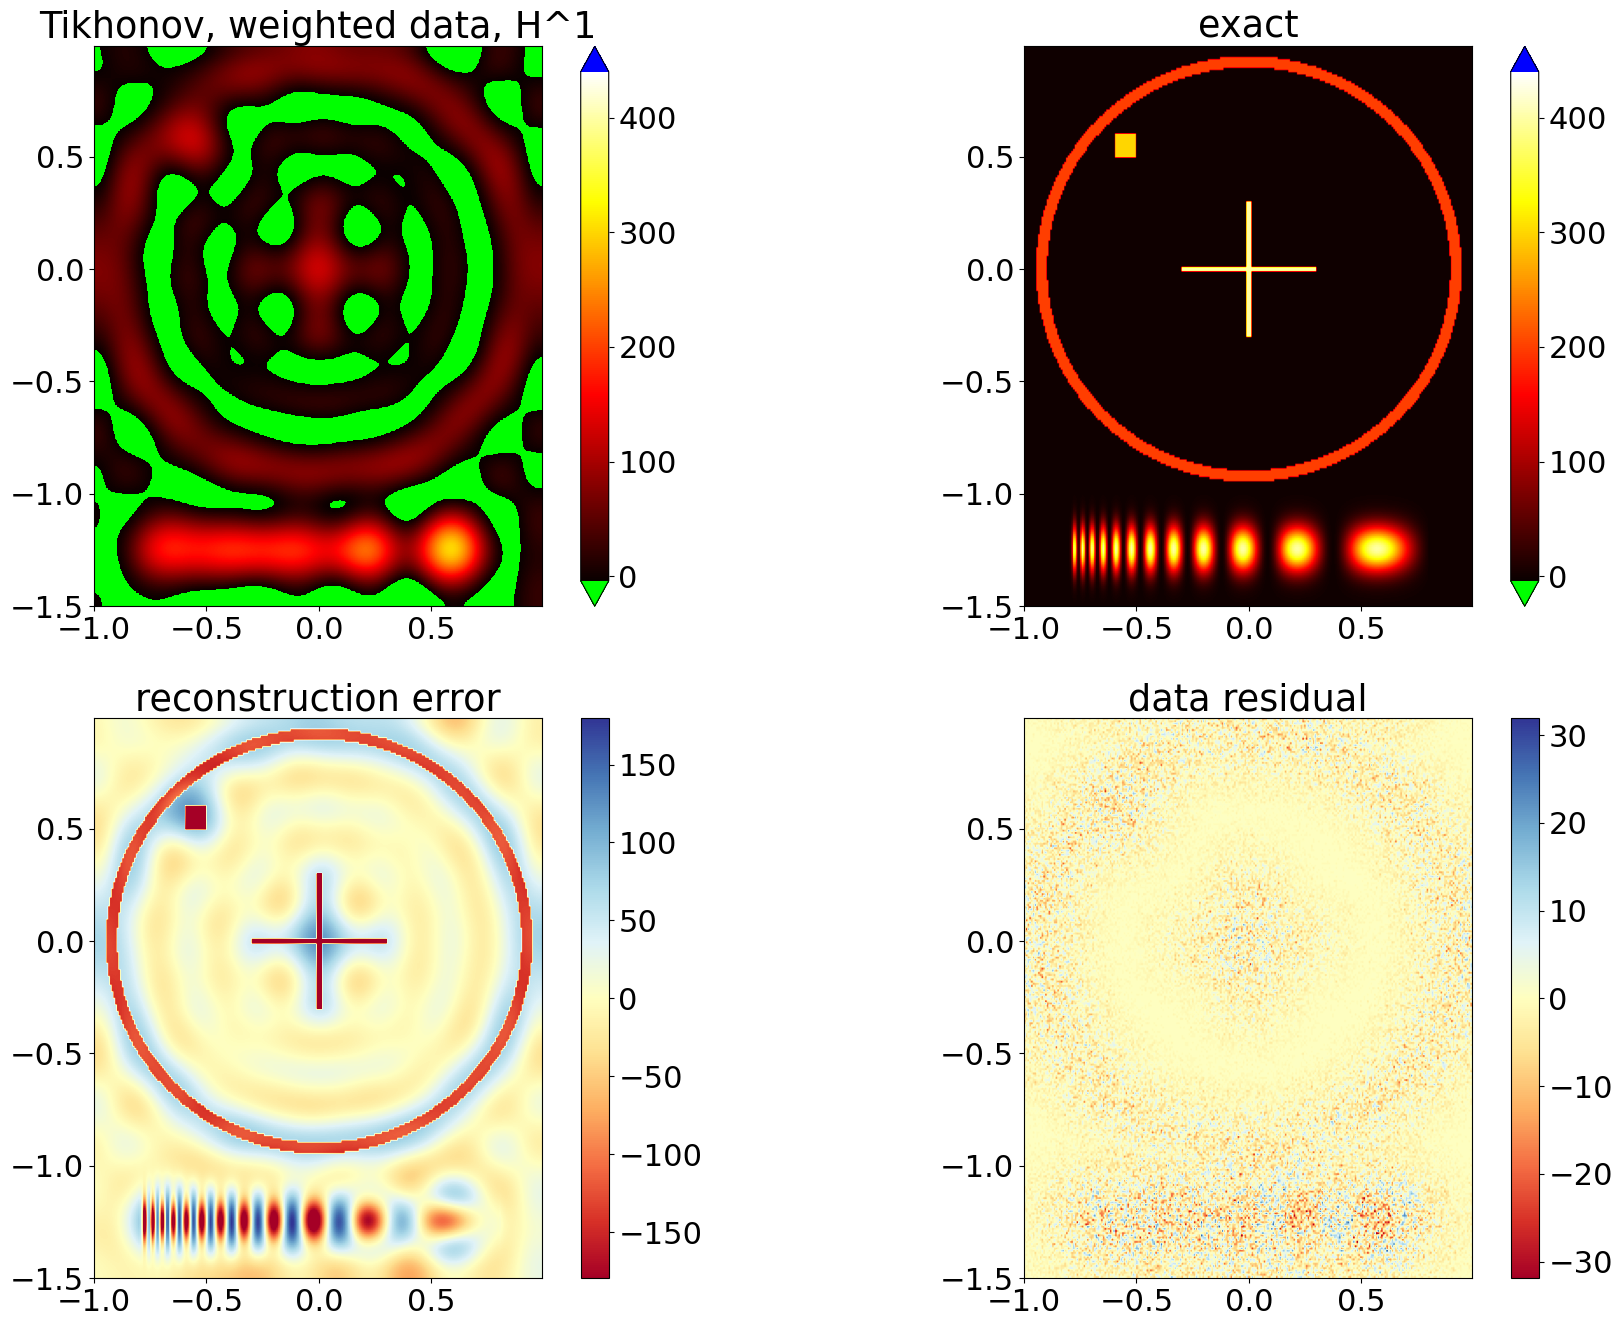

In [67]:
emb = CoordinateProjection(grid,support_bound).adjoint
m=1; pen = HmDomain(grid, support_bound, index = m)
# Sobolev space on the domain D given by largebox of index m
setting = RegularizationSetting(op=conv*emb, penalty=pen, data_fid=h_codomain)
solver = NonstationaryIteratedTikhonov(setting,data,(1e-6,1/2))
max_its= 20
stoprule =  (rules.CountIterations(max_iterations=max_its)
   +rules.Discrepancy(setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(np.sqrt(data[:])), tau=1.02)
)
reco, reco_data = solver.run(stoprule)
print('relative reconstruction error:', np.linalg.norm(emb(reco)[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,emb(reco),title_left="Tikhonov, weighted data, H^{}".format(m),residual = reco_data-data)